In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.588152,0.197948,-0.742601,1.261227,0.449573,0
1,0.308259,-0.813329,-3.385194,0.103437,0.475685,0
2,-0.220702,1.044921,0.249370,0.180255,-1.746878,1
3,-1.409112,-0.491870,-1.260577,1.922582,-0.273073,0
4,-1.136088,0.342823,0.810289,2.434966,0.006969,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)
     

In [8]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df
     

In [9]:

# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [11]:
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_508940/4277182917.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [12]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_508940/4277182917.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [13]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_508940/4277182917.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [14]:

print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col5', 'col3', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [15]:

df3.sample(5)

,col3,col2,target
7,-1.655268,-3.597034,0
61,0.205077,1.001370,1
3,-1.260577,-0.491870,0
55,-4.873401,-2.801698,0
43,-1.468708,0.407588,0


In [16]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     

In [17]:

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [18]:

from sklearn.tree import plot_tree

[Text(0.625, 0.9, 'x[0] <= 0.756\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.5, 0.7, 'x[1] <= 0.966\ngini = 0.284\nsamples = 35\nvalue = [6.0, 29.0]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[1] <= 0.913\ngini = 0.069\nsamples = 28\nvalue = [1, 27]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 25\nvalue = [0, 25]'),
 Text(0.375, 0.3, 'x[0] <= -1.916\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.5, 'x[0] <= -1.746\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.625, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.75, 0.7, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.6875, 0.8, '  False')]

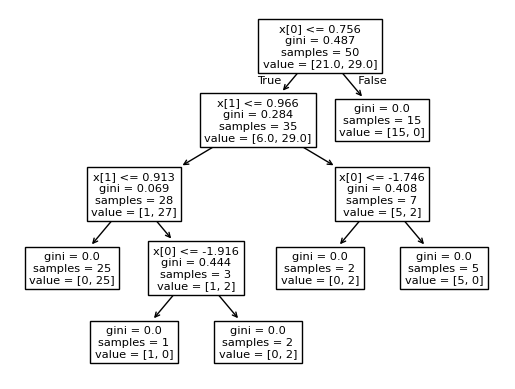

In [19]:
plot_tree(clf1)

[Text(0.6, 0.9, 'x[0] <= 0.851\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.4, 0.7, 'x[1] <= -2.554\ngini = 0.408\nsamples = 35\nvalue = [10, 25]'),
 Text(0.5, 0.8, 'True  '),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.6, 0.5, 'x[1] <= -0.5\ngini = 0.191\nsamples = 28\nvalue = [3, 25]'),
 Text(0.4, 0.3, 'x[0] <= -2.085\ngini = 0.444\nsamples = 9\nvalue = [3, 6]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.3, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.8, 0.7, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.7, 0.8, '  False')]

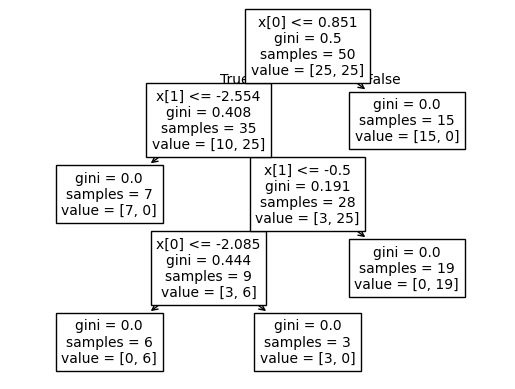

In [20]:
plot_tree(clf2)

[Text(0.5, 0.875, 'x[0] <= 0.191\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.25, 0.625, 'x[1] <= 0.919\ngini = 0.198\nsamples = 27\nvalue = [24, 3]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gini = 0.0\nsamples = 24\nvalue = [24, 0]'),
 Text(0.375, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.75, 0.625, 'x[1] <= -0.432\ngini = 0.083\nsamples = 23\nvalue = [1, 22]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= -0.589\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.75, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.375, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]')]

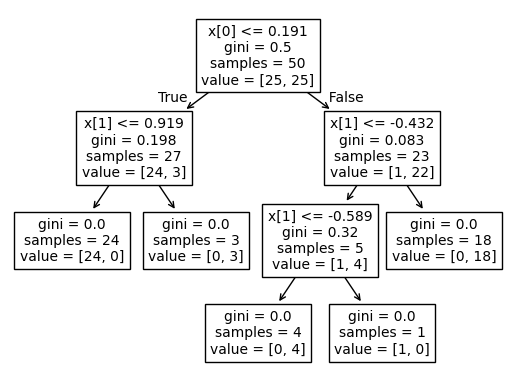

In [21]:
plot_tree(clf3)

In [22]:

clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/home/nirdesho6o/miniconda3/envs/jupyter_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [23]:

df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
81,2.262954,-0.306176,0.237960,0.293644,-1.094560,1
89,-3.630700,-1.612736,0.837545,3.178988,0.668484,0
66,-0.955106,-2.458159,-1.807715,1.013417,0.544601,0
4,-1.136088,0.342823,0.810289,2.434966,0.006969,0
43,-2.349818,0.407588,-1.468708,0.393683,3.177187,0
35,-1.819564,-0.542416,0.176815,1.669793,1.206245,0
60,1.132875,2.065024,3.540094,-3.458003,1.151338,1
84,-2.617824,-0.656368,-2.883151,1.838914,-0.011694,0
62,2.562388,2.036193,-2.308016,0.120342,-4.778239,1
36,1.568254,-2.814871,-1.318327,-0.926577,2.008345,0
